# Task 1.1 — ResNet-152 Frozen-Backbone Baseline

Goal:
Use an ImageNet-pretrained ResNet-152 on CIFAR-10 by freezing the pretrained
backbone and training only a new 10-class classification head.

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
!find /content/drive/MyDrive -type d -name "cifar-10-batches-py"

/content/drive/MyDrive/ATML/data/cifar-10-batches-py


In [5]:
import random
import numpy as np
import torch
import torch.nn as nn

from torchvision import datasets
from torchvision.models import resnet152, ResNet152_Weights
from torch.utils.data import DataLoader, random_split

import matplotlib.pyplot as plot

In [6]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device: ", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device:  cuda
GPU: Tesla T4


In [8]:
classes = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

In [9]:
weights = ResNet152_Weights.DEFAULT
transform = weights.transforms() #! creates required preprocessing pipeline

DATA_PATH = "/content/drive/MyDrive/ATML/data"

full_train_dataset = datasets.CIFAR10(
    root = DATA_PATH,
    train = True,
    download= True, #! if training data exists, use it otherwise download it
    transform= transform
)

train_size = int(0.8 * len(full_train_dataset))
validation_size = len(full_train_dataset) - train_size

generator = torch.Generator().manual_seed(SEED) #! same split

train_dataset, validation_dataset = random_split( full_train_dataset, [train_size, validation_size], generator= generator)

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle= True, num_workers= 0)

validation_loader = DataLoader(validation_dataset, batch_size= BATCH_SIZE, shuffle= False, num_workers=0)

print("Training Samples: ", len(train_dataset))
print("Validation Samples: ", len(validation_dataset))

Training Samples:  40000
Validation Samples:  10000


In [10]:
model = resnet152(weights= weights)

for parameter in model.parameters(): #! Freeze the pretrained model
    parameter.requires_grad = False

number_of_features = model.fc.in_features
model.fc = nn.Linear(number_of_features, len(classes))

model = model.to(device)

print(model.fc)


Downloading: "https://download.pytorch.org/models/resnet152-f82ba261.pth" to /root/.cache/torch/hub/checkpoints/resnet152-f82ba261.pth


100%|██████████| 230M/230M [00:01<00:00, 162MB/s]


Linear(in_features=2048, out_features=10, bias=True)


In [11]:
loss = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.fc.parameters(), lr = 0.001)
#! adam updates weights calculated by backpropogating

In [12]:
EPOCHS = 5
training_losses = []
validation_losses = []

training_accuracies = []
validation_accuracies = []

for epoch in range(EPOCHS):
    model.eval()
    model.fc.train()

    running_loss = 0.0
    correct_predictions = 0
    total_predictions = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad() #! clear gradients
        outputs = model(images) #! model's prediction
        batch_loss = loss(outputs, labels) #! loss
        batch_loss.backward() #! backpropogate
        optimizer.step() #! update the weights

        running_loss += batch_loss.item() * labels.size(0)
        _, predicted = torch.max(outputs, 1)

        total_predictions += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

    training_accuracy = (correct_predictions / total_predictions) * 100
    average_training_loss = (running_loss / total_predictions)

    model.eval()

    validation_running_loss = 0.0
    validation_correct_predictions = 0
    validation_total_predictions = 0

    with torch.no_grad():

        for images, labels in validation_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            validation_running_loss += loss(outputs, labels).item() * labels.size(0)

            _, predicted = torch.max(outputs, 1)

            validation_total_predictions += labels.size(0)

            validation_correct_predictions += (predicted == labels).sum().item()

    validation_accuracy = (validation_correct_predictions / validation_total_predictions) * 100
    average_validation_loss = (validation_running_loss) / validation_total_predictions

    training_losses.append(average_training_loss)
    training_accuracies.append(training_accuracy)
    validation_losses.append(average_validation_loss)
    validation_accuracies.append(validation_accuracy)

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Training Loss: {average_training_loss:.4f} | "
        f"Training Accuracy: {training_accuracy:.2f}% | "
        f"Validation Loss: {average_validation_loss:.4f} | "
        f"Validation Accuracy: {validation_accuracy:.2f}%"
    )

Epoch 1/5 | Training Loss: 0.2728 | Training Accuracy: 92.62% | Validation Loss: 0.1698 | Validation Accuracy: 94.70%
Epoch 2/5 | Training Loss: 0.1445 | Training Accuracy: 95.36% | Validation Loss: 0.1589 | Validation Accuracy: 94.66%
Epoch 3/5 | Training Loss: 0.1172 | Training Accuracy: 96.26% | Validation Loss: 0.1494 | Validation Accuracy: 95.02%
Epoch 4/5 | Training Loss: 0.0991 | Training Accuracy: 96.85% | Validation Loss: 0.1581 | Validation Accuracy: 94.56%
Epoch 5/5 | Training Loss: 0.0865 | Training Accuracy: 97.31% | Validation Loss: 0.1529 | Validation Accuracy: 94.83%


In [13]:
np.savez(
    "/content/drive/MyDrive/ATML/baseline_metrics.npz",
    training_losses=training_losses,
    validation_losses=validation_losses,
    training_accuracies=training_accuracies,
    validation_accuracies=validation_accuracies
)

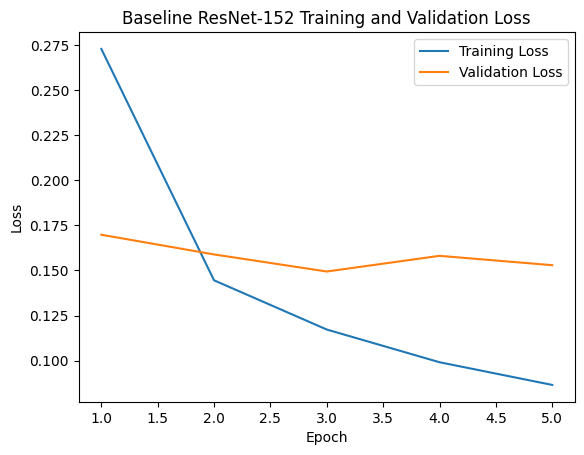

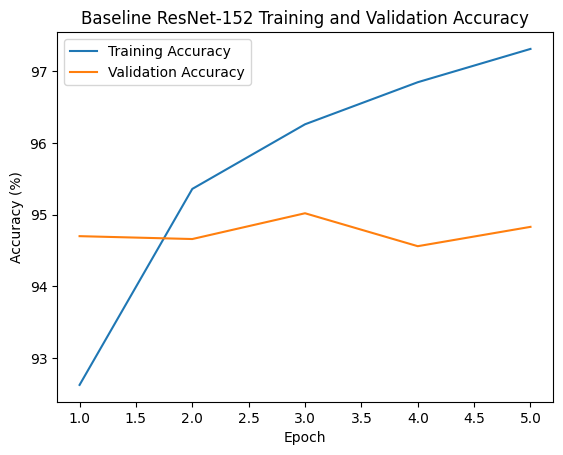

In [14]:
epochs = range(1, EPOCHS + 1)

plot.figure()
plot.plot(epochs, training_losses, label = "Training Loss")
plot.plot(epochs, validation_losses, label = "Validation Loss")

plot.xlabel("Epoch")
plot.ylabel("Loss")
plot.title("Baseline ResNet-152 Training and Validation Loss")
plot.legend()
plot.show()

plot.figure()
plot.plot(epochs, training_accuracies, label = "Training Accuracy")
plot.plot(epochs, validation_accuracies, label = "Validation Accuracy")

plot.xlabel("Epoch")
plot.ylabel("Accuracy (%)")
plot.title("Baseline ResNet-152 Training and Validation Accuracy")
plot.legend()
plot.show()